# **Week 7 – Model Optimisation & Trade-offs**

Name: Rhys Brown

## **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

from scipy.stats import randint

pd.set_option("display.width", 120)
print("Libraries have been loaded successfully.")

from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, f1_score, recall_score,
)

Libraries have been loaded successfully.


## **Import Dataset**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/Carisurg_AI_Training_Program/data/yaleemmlc_admissionprediction_triage.csv"

# index_col=0 drops the unnamed export row-number column (see the identifiers note below).
df_raw = pd.read_csv(DATA_PATH, index_col=0)
print(f"Loaded {df_raw.shape[0]:,} ED encounters  x  {df_raw.shape[1]} columns")

Mounted at /content/drive
Loaded 55,121 ED encounters  x  225 columns


In [4]:
df_raw.head()

,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,employstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,Retired,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,Disabled,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,Full Time,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,Full Time,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,Not Employed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
df = df_raw.copy()

# drop any stray index column (e.g. "Unnamed: 0") that pandas adds — it is not real data
df = df.drop(columns=[c for c in df.columns if c.startswith("Unnamed")], errors="ignore")

# 1) force the vitals to be NUMBERS; unparseable text (e.g. "120bpm") becomes NaN
for col in VITALS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 2) the ESI label must be 1-5. Drop rows where it is missing or out of range —
#    a row with no valid triage label cannot teach a triage model.
df["esi"] = pd.to_numeric(df["esi"], errors="coerce")
df = df[df["esi"].isin([1, 2, 3, 4, 5])].copy()

# 3) blank out physically impossible vitals so they don't poison the model
df.loc[(df["triage_vital_temp"] < 90) | (df["triage_vital_temp"] > 110), "triage_vital_temp"] = np.nan
df.loc[df["triage_vital_o2"] > 100, "triage_vital_o2"] = np.nan

# 4) encode gender to 0/1 (handles odd casings like "m" / "MALE")
df["gender"] = df["gender"].astype(str).str.strip().str.lower().map(
    {"male": 0, "m": 0, "female": 1, "f": 1})

# 5) fill remaining missing NUMBERS with the column median (simple and defensible)
for col in VITALS + ["age", "gender"]:
    df[col] = df[col].fillna(df[col].median())

df["esi"] = df["esi"].astype(int)
print("Modelling table ready:", df.shape)
df["esi"].value_counts().sort_index()

Modelling table ready: (55121, 225)


,count
esi,
1,77
2,17924
3,27010
4,8896
5,1214


In [6]:
categorical_cols = df_raw.select_dtypes(include=['object', 'category']).columns.tolist()
print("Categorical columns in df_raw:", categorical_cols)

Categorical columns in df_raw: ['dep_name', 'gender', 'ethnicity', 'race', 'lang', 'religion', 'maritalstatus', 'employstatus', 'insurance_status', 'disposition', 'arrivalmode', 'arrivalmonth', 'arrivalday', 'arrivalhour_bin', 'previousdispo']


## **Column Organization**

In [7]:
TARGET = "esi"

# Vital-sign columns measured at the front door:
VITALS = ["triage_vital_hr", "triage_vital_sbp", "triage_vital_dbp", "triage_vital_rr",
          "triage_vital_o2", "triage_vital_temp", "triage_glucose"]
# Who the patient is (some of these are fairness-sensitive — handle with care):
DEMOGRAPHICS = ["age", "gender", "ethnicity", "race", "lang", "religion",
                "maritalstatus", "employstatus", "insurance_status"]
# Administrative / arrival details:
ADMIN = ["dep_name", "arrivalmode", "arrivalmonth", "arrivalday", "arrivalhour_bin"]
# OUTCOMES of the visit — known only AFTER triage, so they must never be model inputs:
LEAKAGE = ["disposition", "previousdispo"]

FEATURES = [c for c in df.columns if c != TARGET and c not in LEAKAGE + ADMIN + DEMOGRAPHICS]

## **Test-train Split**

In [8]:
X, y = df[FEATURES], df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 44096 | test: 11025


## **Scaling of Test and Train Dataset for Dependent Variables**

Logistic Regression requires the features to be scaled before the model is trained on them.

In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train) # trains standard scaler on X_train
X_test_scaled = scaler.transform(X_test) # uses same standard deviations from X_train to scale X_test

## **Baseline Model from Week 6**

In [10]:
baseline = make_pipeline(StandardScaler(),
                         LogisticRegression(max_iter=1000, random_state=42))
baseline_model = baseline.fit(X_train_scaled, y_train)
print(classification_report(y_test, baseline_model.predict(X_test_scaled)))

              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



## **Feature Engineering**

In [30]:
def add_clinical_features(old_df):
  """
    Creates newly engineered features to improve the performance of the model.
    Args: Raw Dataframe with no engineered features
    Returns: New Dataframe with engineered features

  """

  new_df = old_df.copy()

  new_df["fe_shock_index"]    = new_df["triage_vital_hr"] / new_df["triage_vital_sbp"]       # HR / SBP         (uses BP)
  new_df["fe_pulse_pressure"] = new_df["triage_vital_sbp"] - new_df["triage_vital_dbp"]      # SBP - DBP        (uses BP)
  new_df["fe_spo2_rr_ratio"]  = new_df["triage_vital_o2"] / new_df["triage_vital_rr"]        # oxygen vs effort (NO BP)

  new_df["fe_is_tachypneic"] = (new_df["triage_vital_rr"]   > 20   ).astype(int)   # fast breathing
  new_df["fe_is_hypoxic"]    = (new_df["triage_vital_o2"]   < 92   ).astype(int)   # low oxygen
  new_df["fe_is_febrile"]    = (new_df["triage_vital_temp"] >= 100.4).astype(int)  # fever

  new_df["fe_is_bradycardic"]    = (new_df["triage_vital_hr"] < 60.0).astype(int)
  new_df["fe_is_hyperglycaemic"]    = (new_df["triage_glucose"] >= 180.0).astype(int)
  new_df["fe_is_hypothermic"]    = (new_df["triage_vital_temp"] < 96.8).astype(int)
  new_df["fe_resp_distress"]    = (new_df["triage_vital_o2"] < 90.0).astype(int) |(new_df["triage_vital_rr"] > 20).astype(int)

  new_df["fe_map_estimate"] = new_df["triage_vital_dbp"] + new_df["fe_pulse_pressure"] / 3.0

  return new_df

In [33]:
X_train_fe = add_clinical_features(X_train)
X_test_fe  = add_clinical_features(X_test)

scaler = StandardScaler()

X_train_scaled_fe = scaler.fit_transform(X_train_fe)
X_test_scaled_fe  = scaler.transform(X_test_fe)

In [34]:
X_train_fe.head()

,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,fe_pulse_pressure,fe_spo2_rr_ratio,fe_is_tachypneic,fe_is_hypoxic,fe_is_febrile,fe_is_bradycardic,fe_is_hyperglycaemic,fe_is_hypothermic,fe_resp_distress,fe_map_estimate
258794,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,49.0,4.454545,1,0,0,0,0,0,1,87.333333
397606,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,39.0,5.333333,0,0,0,0,0,0,0,89.000000
100469,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,41.0,5.222222,0,0,0,0,0,0,0,91.666667
428649,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,35.0,6.125000,0,0,0,0,0,0,0,104.666667
81548,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,35.0,5.444444,0,0,0,0,0,0,0,89.666667


In [35]:
baseline_model_fe = baseline.fit(X_train_scaled, y_train)
print(classification_report(y_test, baseline_model_fe.predict(X_test_scaled)))

              precision    recall  f1-score   support

           1       0.44      0.25      0.32        16
           2       0.72      0.61      0.66      3585
           3       0.66      0.76      0.71      5402
           4       0.61      0.59      0.60      1779
           5       0.48      0.11      0.18       243

    accuracy                           0.67     11025
   macro avg       0.58      0.46      0.49     11025
weighted avg       0.67      0.67      0.66     11025



## **Categorical Feature Encoding**

Clinical Justification for the inclusion of age and gender demographics:
- **Age:** Age shows direct corelation with increased acuity levels. This relationship makes sense as age is typically associated with poor health.
- **Gender:** While it must be handled carefully, gender is an important feature as some conditions are gender specific and as such must be addressed separately.

All other demographics such as race, ethinicity or religion were **not** included due to concerns regarding fairness or clinical relevance.


In [36]:
def add_demographics(X_fe):
    """Bolt the encoded demographics onto an existing feature frame (aligned by row)."""
    rows = X_fe.index
    extra = demo_1hot.loc[rows].copy()

    #Include age and gender back in final dataset.

    extra["age"] = df.loc[rows, "age"]         # numeric already
    extra["gender"] = df.loc[rows, "gender"]   # 0/1 already
    return pd.concat([X_fe, extra], axis=1)

X_train_plus = add_demographics(X_train_fe)
X_test_plus = add_demographics(X_test_fe)

In [37]:
X_train_plus.head()


,triage_vital_hr,triage_vital_sbp,triage_vital_dbp,triage_vital_rr,triage_vital_o2,triage_vital_o2_device,triage_vital_temp,triage_glucose,cc_abdominalcramping,cc_abdominaldistention,...,race_American Indian or Alaska Native,race_Asian,race_Black or African American,race_Native Hawaiian or Other Pacific Islander,race_Other,race_Patient Refused,race_Unknown,race_White or Caucasian,age,gender
258794,104.0,120.0,71.0,22.0,98.0,1.0,98.2,137.0,0.0,0.0,...,0,0,0,0,1,0,0,0,69.0,1
397606,78.0,115.0,76.0,18.0,96.0,0.0,98.4,102.0,0.0,0.0,...,0,0,0,0,0,0,0,1,38.0,0
100469,96.0,119.0,78.0,18.0,94.0,0.0,98.1,108.0,0.0,0.0,...,0,0,0,0,0,0,0,1,51.0,0
428649,89.0,128.0,93.0,16.0,98.0,0.0,97.7,108.0,0.0,0.0,...,0,0,1,0,0,0,0,0,80.0,1
81548,89.0,113.0,78.0,18.0,98.0,0.0,98.1,92.0,0.0,0.0,...,0,0,0,0,0,0,0,1,34.0,0


In [38]:
X_train_plus["gender"].value_counts()

,count
gender,
1,25363
0,18733


## **Training Machine Learning Models**

### ***Model 1 - Random Forest Classifier***

In [39]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [40]:
rf_model_fe = RandomForestClassifier(random_state=42, n_estimators=300, max_depth=None, class_weight='balanced', n_jobs=-1)
rf_model_fe.fit(X_train_fe, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=300, n_jobs=-1,
                       random_state=42)

In [43]:
param_dist = {
    'n_estimators': randint(100, 500), # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': randint(10, 100), # Maximum number of decisions per tree
    'min_samples_split': randint(2, 20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(1, 10), # Minimum number of samples required to be at a leaf node
    'class_weight': ['balanced', 'balanced_subsample', None] # Class weights to deal with severe class imbalance
}

search_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=30,
    cv=3,
    scoring="f1_macro",
    #n_jobs=-1,
    verbose=3
)

search_rf.fit(X_train_plus, y_train)
print("Best hyperparameters:", search_rf.best_params_)

rf_model_plus = search_rf.best_estimator_

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV 1/3] END class_weight=None, max_depth=67, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=282;, score=0.362 total time=  34.9s
[CV 2/3] END class_weight=None, max_depth=67, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=282;, score=0.363 total time=  59.2s
[CV 3/3] END class_weight=None, max_depth=67, max_features=sqrt, min_samples_leaf=8, min_samples_split=8, n_estimators=282;, score=0.361 total time=  29.5s
[CV 1/3] END class_weight=balanced_subsample, max_depth=42, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, n_estimators=400;, score=0.459 total time=  36.8s
[CV 2/3] END class_weight=balanced_subsample, max_depth=42, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, n_estimators=400;, score=0.457 total time=  33.8s
[CV 3/3] END class_weight=balanced_subsample, max_depth=42, max_features=sqrt, min_samples_leaf=6, min_samples_split=2, n_estimator

In [44]:
print("Random Forest with no Engineered Features")
print(classification_report(y_test, rf_model.predict(X_test)))

print("Random Forest with Engineered Features alone")
print(classification_report(y_test, rf_model_fe.predict(X_test_fe)))

print("Random Forest with Engineered Features and encoded categorical features")
print(classification_report(y_test, rf_model_plus.predict(X_test_plus)))

Random Forest with no Engineered Features


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.71      0.61      0.66      3585
           3       0.65      0.76      0.70      5402
           4       0.60      0.51      0.55      1779
           5       0.40      0.12      0.18       243

    accuracy                           0.66     11025
   macro avg       0.47      0.40      0.42     11025
weighted avg       0.65      0.66      0.65     11025

Random Forest with Engineered Features alone


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.71      0.56      0.62      3585
           3       0.62      0.81      0.70      5402
           4       0.62      0.37      0.46      1779
           5       0.39      0.09      0.14       243

    accuracy                           0.64     11025
   macro avg       0.47      0.37      0.39     11025
weighted avg       0.64      0.64      0.62     11025

Random Forest with Engineered Features and encoded categorical features
              precision    recall  f1-score   support

           1       0.36      0.31      0.33        16
           2       0.67      0.66      0.66      3585
           3       0.70      0.61      0.65      5402
           4       0.47      0.66      0.55      1779
           5       0.36      0.37      0.36       243

    accuracy                           0.63     11025
   macro avg       0.51      0.52      0.51     11025
weigh

In [45]:
rf_optimized = rf_model_plus

In [46]:
pd.Series(rf_optimized.feature_importances_, index=X_train_plus.columns)

,0
triage_vital_hr,0.043651
triage_vital_sbp,0.053122
triage_vital_dbp,0.046830
triage_vital_rr,0.022294
triage_vital_o2,0.027289
...,...
race_Patient Refused,0.000711
race_Unknown,0.000250
race_White or Caucasian,0.008901
age,0.066698


In [58]:
joblib.dump(rf_optimized, "/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/rf_optimized.joblib")
print("Saved random forest securely to Google Drive!")

Saved random forest securely to Google Drive!


### ***Model 2 - Gradient Boosting Classifier***

In [ ]:
"""
param_dist_gb_old = {
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_iter": [50, 100, 150, 200],          #
    "max_depth": [4, 6, 10, 15],
    "min_samples_leaf": [10, 20, 50, 100],
    "l2_regularization": [0.0, 0.1, 1.0, 10.0]
}
"""


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from scipy.stats import randint, uniform

param_dist_gb = {
    "learning_rate": uniform(0.01, 0.24),  # Controls how aggressively trees correct prior errors
    "max_iter": randint(50, 300),  # Number of sequential trees
    "max_depth": randint(4, 21), # Tree depth limit to prevent overfitting
    "min_samples_leaf": randint(10, 150),
    "l2_regularization": uniform(0.0, 10.0) # Penalizes extreme splits to keep predictions robust
}

search_gb = RandomizedSearchCV(
    estimator=HistGradientBoostingClassifier(
        class_weight="balanced",
        categorical_features="from_dtype",
        random_state=42
    ),
    param_distributions=param_dist_gb,
    n_iter=30,
    cv=3,
    scoring="f1_macro",
    verbose=3
)

print("Starting Gradient Boosting Hyperparameter Search...")
search_gb.fit(X_train_fe, y_train)

print("Gradient Boosting Hyperparameter Search Complete!")
print("\nBest Gradient Boosting Parameters:", search_gb.best_params_)
gb_optimized = search_gb.best_estimator_

In [ ]:
joblib.dump(gb_optimized, "/content/drive/MyDrive/Carisurg_AI_Training_Program/notebooks/week-7/best_gb_model.joblib")
print("Saved gradient boosting securely to Google Drive!")

### ***Model 3 - Multi-Layer Perceptron Classifier***

In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from scipy.stats import randint, uniform

param_dist_mlp = {
      "alpha": uniform(0.0001, 0.01),
      "hidden_layer_sizes": [(64,32), (16, 8), (32,8)],
      "max_iter": randint(50, 300)
}

search_mlp = RandomizedSearchCV(
    estimator=make_pipeline(
        StandardScaler(),
        MLPClassifier(random_state=42)
    ),
    param_distributions=param_dist_mlp,
    n_iter=30,
    cv=3,
    scoring="f1_macro",
    verbose=3
)

print("Starting MLP Hyperparameter Search...")
search_gb.fit(X_train_fe, y_train)

print("MLP Search Complete!")
print("\nBest Gradient Boosting Parameters:", search_gb.best_params_)
gb_optimized = search_gb.best_estimator_

## **Evaluating Accuracy, Precision, Recall and F1-Score of trained Machine Learning Models**

In [49]:
print("Best Random Forest Model")
print(classification_report(y_test, rf_optimized.predict(X_test_plus)))

"""
print("Best GB Model")
print(classification_report(y_test, gb_optimized.predict(X_test_fe)))
"""


Best Random Forest Model
              precision    recall  f1-score   support

           1       0.36      0.31      0.33        16
           2       0.67      0.66      0.66      3585
           3       0.70      0.61      0.65      5402
           4       0.47      0.66      0.55      1779
           5       0.36      0.37      0.36       243

    accuracy                           0.63     11025
   macro avg       0.51      0.52      0.51     11025
weighted avg       0.64      0.63      0.63     11025



'\nprint("Best GB Model")\nprint(classification_report(y_test, gb_optimized.predict(X_test_fe)))\n'

## **Confusion Matricies of trained Machine Learning Models**

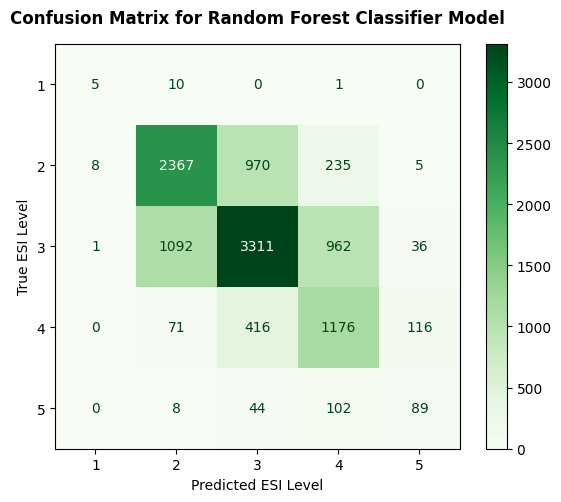

In [48]:
pred_rf = rf_optimized.predict(X_test_plus)

fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, ax=ax, cmap="Greens", values_format='d')
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Confusion Matrix for Random Forest Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_rf.png", dpi=300)
plt.show()

In [ ]:
pred_gb = gb_optimized.predict(X_test_fe)

fig, ax = plt.subplots(figsize=(6, 5))
cm = ConfusionMatrixDisplay.from_predictions(y_test, pred_gb, ax=ax, cmap="Reds", values_format='d')
ax.set_xlabel("Predicted ESI Level")
ax.set_ylabel("True ESI Level")
ax.set_title("Confusion Matrix for Gradient Boosting Classifier Model", fontsize=12, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("cm_gb.png", dpi=300)
plt.show()

## **Benchmarking the Models**

In [56]:
import timeit
import random
from sklearn.metrics import recall_score, f1_score

benchmark_df = pd.DataFrame(columns=["Model", "Accuracy", "Recall ESI 1", "Macro F1", "Training Time", "Inference Time", "Explainability"])

random_idx = random.randint(2, len(X_train_plus) - 1)
single_sample = X_train_plus.iloc[[random_idx]]

rf_benchmark = {
    "Model": "Random Forest",
    "Accuracy": round(rf_optimized.score(X_test_plus, y_test), 2),
    "Recall ESI 1": round(recall_score(y_test, pred_rf, average="macro"), 2),
    "Macro F1": round(f1_score(y_test, pred_rf, average="macro"), 2),
    "Training Time": "42 mins",
    "Inference Time": f"{round((timeit.timeit(lambda: rf_optimized.predict(single_sample), number=100)/100.0)*1000 , 2)}ms",
    "Explainability": "Medium"
}

rf_benchmark_df = pd.DataFrame([rf_benchmark])
benchmark_df = pd.concat([benchmark_df, rf_benchmark_df], ignore_index=True)


/tmp/ipykernel_2032/2145893727.py:21: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  benchmark_df = pd.concat([benchmark_df, rf_benchmark_df], ignore_index=True)


In [57]:
benchmark_df.head()

,Model,Accuracy,Recall ESI 1,Macro F1,Training Time,Inference Time,Explainability
0,Random Forest,0.63,0.52,0.51,42 mins,23.56ms,Medium
